# OpenMC-Based Physics-Informed Genetic Algorithm for BWR Fuel Assembly Enrichment Layout

*An OpenMC-coupled, symmetry-aware GA for binary-enrichment pin layout design, benchmarked against the Gundremmingen-A BWR 6×6 assembly*

---

## Introduction

This notebook couples a Genetic Algorithm (GA) to **OpenMC** — an open-source, continuous-energy Monte Carlo neutron transport code — to optimise the spatial layout of a fixed enrichment inventory in a Boiling Water Reactor (BWR) fuel assembly. Each candidate layout is a binary chromosome decoded into a physical enrichment map, simulated in OpenMC, and scored against two reactor-physics targets: an infinite-lattice multiplication factor $k_{\infty}$ and a power-peaking safety limit PPF. The GA evolves a population of layouts over several generations, using OpenMC's neutronic feedback directly as the fitness signal.

The reference case follows the Gundremmingen-A BWR 6×6 benchmark of Radaideh et al. (2021), who report a feasible pattern satisfying three simultaneous gates: an average enrichment $\bar{E} \approx 2.3\%$, PPF $<$ 1.35, and $k_{\infty} \approx 1.25$. This notebook adopts a fixed inventory of **23 high-enrichment (2.53 wt%) and 13 low-enrichment (1.87 wt%) rods**, giving $\bar{E} = (2.53 \times 23 + 1.87 \times 13)/36 = 2.292\%$ — the only integer split landing on exactly that value, and close to Radaideh et al.'s reported target. Readers should consult the primary paper directly for its exact reference inventory, since other patterns described there use different splits. This notebook therefore searches only over *where* those 23 rods are placed — the spatial arrangement problem, not the inventory-selection problem.

The neutronics solver differs from the original benchmark: Radaideh et al. used CASMO4 (a deterministic lattice code), whereas this notebook uses OpenMC (Monte Carlo). Absolute $k_{\infty}$ and PPF values for a given layout may therefore differ slightly between the two, though the optimisation problem and feasibility criteria are identical.

Although the notebook and underlying platform are written generically for an N×N assembly (configurable via `BWR_N` and `N_HIGH_RODS`), every fixed parameter, benchmark comparison, and validated result described below is specific to the N = 6 case. Changing `BWR_N` reframes the problem to a different assembly size and rod inventory that has not been benchmarked or physically validated in this notebook.

---
## 1. Why a Genetic Algorithm?

The enrichment-layout problem is fundamentally **discrete and combinatorial**. The 21 symmetry-reduced positions split into 6 diagonal cells (each worth one physical pin) and 15 off-diagonal pairs (each worth two mirrored pins), so filling the fixed inventory of 23 high-enrichment rods means picking some mix of diagonal cells and off-diagonal pairs whose pin counts add up to exactly 23. Counting every such mix gives roughly 9.8×10⁴ valid layouts — comfortably in the $10^4$–$10^5$ range.

This space is too large to enumerate exhaustively — each layout requires a full OpenMC run — but too structured to search blindly at random. The GA is well suited here for several reasons:

- **Population diversity.** A population of candidate layouts explores multiple regions of the design space simultaneously, reducing the risk of getting
  trapped in a local optimum.
- **Inventory-safe operators.** Swap-mutation and repair-after-crossover guarantee the 23/13 rod count is preserved at every step — no wasted OpenMC evaluations on infeasible layouts.
- **Physics-informed initialisation.** Corner masking and adjacency constraints can be encoded directly into the chromosome representation, biasing the search toward physically sensible regions before any OpenMC call is made.
- **No gradient required.** The GA treats OpenMC as a pure black box — it only needs the scalar fitness value returned, not any derivative of $k_{\infty}$ or PPF with respect to pin positions.

This notebook also serves as a **baseline and warm-start** for the companion Hybrid Optimisation notebook (HO-BO), where the GA's elite chromosomes seed the Bayesian Optimisation surrogate. The standalone GA result quantifies how much the BO fine-tuning phase adds on top of the GA's global scouting.

---


## 2. Physical Model and Enrichment Representation

| Chromosome Bit | Fuel Type | U-235 Enrichment |
| :---: | :---: | :---: |
| `0` | Low-enrichment UO₂ | 1.87 wt% |
| `1` | High-enrichment UO₂ | 2.53 wt% |

| Parameter | Value |
| :--- | :---: |
| Assembly size | 6×6 (36 pins) |
| Symmetry-reduced chromosome length | 21 |
| High-enrichment rods (fixed) | 23 |
| Low-enrichment rods (fixed) | 13 |
| Average enrichment E | 2.292 wt% |
| Target k∞ | 1.25 |
| PPF limit | < 1.35 |

The 23/13 split is held fixed throughout the GA — mutation and crossover are repaired as needed to preserve it — so every candidate the GA evaluates automatically satisfies the economic/inventory gate (E = 2.292%) by construction, and the search only resolves the remaining two gates: the PPF safety limit and the k∞ target.

The OpenMC model represents a single, isolated assembly under **reflective boundary conditions**, the standard way to approximate an infinite, repeating lattice of identical assemblies. The resulting eigenvalue is therefore the assembly's **infinite multiplication factor, k∞** — not the full-core effective multiplication factor, k_eff, which additionally reflects neutron leakage from a finite core, control rods, burnup history, and neighboring assemblies.

---

## 3. GA Workflow

Each generation alternates between **expensive OpenMC evaluation** and **cheap genetic operations**. The goal is to evolve the population toward layouts that satisfy both the $k_{\infty}$ target and the PPF limit.

```
Phase A — Initialisation
  Generate population of valid chromosomes (inventory constraint enforced)
  Apply corner masking if enabled (hard constraint at chromosome level)
              |
              ▼
Phase B — OpenMC Evaluation
  Decode each chromosome -> binary enrichment grid
  Run OpenMC -> collect k∞, PPF per individual
  Compute fitness F for each individual
              |
              ▼
Phase C — Selection + Breeding
  Tournament selection -> crossover -> swap-mutation
  Repair offspring to restore 23/13 inventory if crossover disturbed it
  Carry elite individuals unchanged (elitism)
              |
              ▼
Phase D — Next Generation
  Replace population with offspring + elites
              |
              ▼
  Repeat Phases B–D for n_generations
              |
              ▼
Phase E — Hall-of-Fame
  Return the single best chromosome seen across all generations
```

- **Phase A (Initialisation)** — creates a population of valid chromosomes using the diagonal/off-diagonal split to enforce the inventory exactly; corner positions are excluded from high-enrichment selection if masking is on.
- **Phase B (OpenMC Evaluation)** — every individual is decoded and evaluated in OpenMC; $k_{\infty}$, PPF, and fitness are recorded.
- **Phase C (Selection + Breeding)** — tournament selection picks parents; two-point crossover produces children; swap-mutation exchanges one HIGH and one LOW bit, conserving the inventory; a repair step corrects any remaining inventory violation after crossover.
- **Phase D (Next Generation)** — the new population replaces the old one, with the top elite individuals carried over unchanged.
- **Phase E (Hall-of-Fame)** — the single best individual ever seen across all generations is returned, regardless of which generation it came from.

---


## 4. Optimization Objective

With the inventory fixed, the GA searches for the spatial arrangement that brings k∞ closest to target while keeping the **Power Peaking Factor (PPF)** — hottest pin's fission rate divided by the assembly average — under the safety limit:

$$k_{\infty} \approx 1.25, \qquad \text{PPF} = \frac{\max(\text{pin-wise fission rate})}{\text{mean}(\text{pin-wise fission rate})} < 1.35$$

Both values come from OpenMC: k∞ from the eigenvalue calculation, PPF from a mesh fission-rate tally used as a simplified pin-power proxy — adequate for beginning-of-life comparisons, though it omits spectral/moderation effects a full pin-power reconstruction would capture.

---

## 5. Fitness Function

The GA is posed as a **minimization problem** — lower is better, zero meaning the k∞ target is hit exactly with no PPF violation:

$$F = \alpha_k \left| k_{\text{target}} - k_{\infty} \right| + \alpha_{\text{PPF}} \max\left(0,\ \text{PPF} - \text{PPF}_{\text{target}}\right)^2 + w_{\text{adj}} \cdot N_{\text{adj}}$$

| Term | Meaning |
| :--- | :--- |
| $k_{\text{target}}$ | target k∞ (1.25) |
| $\text{PPF}_{\text{target}}$ | PPF limit (1.35) |
| $\alpha_k$, $\alpha_{\text{PPF}}$ | weights on each deviation |
| $w_{\text{adj}}$, $N_{\text{adj}}$ | optional adjacency-penalty weight and count of adjacent high-enrichment pairs |

The PPF term only activates once the limit is exceeded, so the GA freely trades off PPF anywhere below 1.35 while chasing the k∞ target.

---

## 6. Scalable N×N Symmetry Architecture

For a general N×N assembly: total pins = $N^2$, independent chromosome positions under 1/2-diagonal symmetry = $\frac{N(N+1)}{2}$. For N = 6 this gives 21 positions instead of 36 — a meaningful search-space reduction, on the assumption that the optimal layout respects diagonal symmetry (a non-symmetric optimum, if one existed, would be excluded by construction). Chromosome length, grid decoding, rod-count bookkeeping, and mutation/repair all derive automatically from N, so scaling up requires no rework of the encoding.

---

## 7. Physics-Informed Constraints

Two optional heuristics bias the search away from physically poor layouts before they ever reach OpenMC:

- **Corner masking (hard constraint).** Prevents high-enrichment rods from occupying the four corners. Corner pins sit at the assembly boundary where neutron leakage is highest, so low-enrichment fuel there reduces leakage and flattens the power distribution — the same mechanism behind the best patterns reported in Radaideh et al. (2021).
- **Adjacency penalty (soft constraint).** Adds a fitness penalty proportional to the number of directly adjacent high-enrichment pairs, discouraging clusters that would create local hot spots, without forbidding them outright.

Both are toggles that bias, not override, the underlying OpenMC-computed k∞ and PPF.

---

## 8. Outputs

The notebook produces the optimized chromosome and decoded 6×6 layout, OpenMC k∞ with uncertainty, PPF and feasibility status, GA fitness and convergence plots, a layout visualization, a high-fidelity re-evaluation of the best layout at higher particle count, a text design report, and a CSV archive of all evaluated chromosomes.

---

## 9. Limitations

This is a research/educational demonstration, **not** a licensed fuel-design tool. It does not model burnup/depletion (beginning-of-life snapshot only), thermal-hydraulic feedback, control rods, axial effects, or finite-core leakage (k∞ ≠ k_eff for a real reactor). PPF is a fission-rate-mesh proxy rather than a full pin-power reconstruction. Most importantly, the GA search uses relatively low particle counts per OpenMC evaluation for runtime reasons, so individual k∞/PPF estimates carry statistical noise that can occasionally affect fitness ranking between close candidates — which is why the notebook ends with a separate high-fidelity validation step at much higher particle counts. For rigorous use, extend the model with depletion, thermal-hydraulic coupling, axial representation, and additional engineering constraints.


# User Inputs
**(Change only `BWR_N` and `N_HIGH_RODS` to switch assembly size.)**

In [12]:
BWR_N        = 6    # –––––> Side length of the square assembly
N_HIGH_RODS  = 23   # –––––> Number of high-enrichment rods in the
                    #   full N×N grid (assembly-specific physics input)

import os
##****** Toggles: Both true ––> toggles turned on; Both False ––> turned off **********#####

ENABLE_CORNER_MASKING = True  #True or False         
ENABLE_ADJACENCY_PENALTY = True      #True or False  

ENABLE_ADJACENCY_PENALTY_WEIGHT = 2.0

ALPHAK = 10
ALPHAPPF = 5

# Scale further by heuristic complexity
use_physics_heuristics = ENABLE_CORNER_MASKING and ENABLE_ADJACENCY_PENALTY

# GA HYPERPARAMETER SCALING LOGIC *******************************************
'''
 Heuristic Constraints: Hard masking reduces the effective search space by removing selected pin positions from the GA decision process. 
                 However, the adjacency penalty is a soft constraint that can increase selection pressure by penalizing clustered 
                 high-enrichment layouts. A mildly higher population can help maintain genetic diversity and reduce the risk of premature convergence.
 
 Assembly Size (NxN): As the assembly size increases, the chromosome length grows approximately with N^2, since the number of pin positions in an 
                      N×N assembly is N^2. However, the number of possible enrichment layouts grows combinatorially. As a result, larger assemblies 
                      may require larger populations and/or more generations to explore the expanded search space.

'''

base_pop = int(60 * (BWR_N / 6))  #60
base_gen = int(80 * (BWR_N / 6))  #80


POPULATION_SIZE = int(base_pop * 1.1) if use_physics_heuristics else base_pop
N_GENERATIONS   = base_gen 

# Auto-derived — do not edit
N_TOTAL      = BWR_N ** 2
N_SYM        = BWR_N * (BWR_N + 1) // 2
suffix       = "HP-GA" if use_physics_heuristics else "GA"
MODEL_NAME   = f"BWR_{BWR_N}x{BWR_N}_{suffix}"
RESULTS_DIR  = f"../Results/{MODEL_NAME}"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"GA Setup complete: {MODEL_NAME}")


GA Setup complete: BWR_6x6_HP-GA


In [13]:

import sys
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)



from openmc_ga import GAConfig, run_ga, run_ga_smoke_test, summarise_ga_results, plot_ga_convergence, make_random_individual


from environments.env        import evaluate_for_ga, get_model_params
from environments.bwr_vis    import plot_enr_grid, validate_and_plot_hifi 
from environments.bwr_report import export_design_report

print("All imports successful.")

All imports successful.


# GA Configuration

In [14]:
cfg_ga = GAConfig(
    # Assembly size 
    n_rods_side  = BWR_N,           
    n_high_rods  = N_HIGH_RODS,     

     
    k_target   = 1.25,
    ppf_target = 1.35,
    alpha_k    = ALPHAK,
    alpha_ppf  = ALPHAPPF,

    # Physics-informed penalties 
    use_corner_masking    = ENABLE_CORNER_MASKING,
    use_adjacency_penalty = ENABLE_ADJACENCY_PENALTY,
    adj_penalty_weight    = ENABLE_ADJACENCY_PENALTY_WEIGHT,

    # GA hyper-parameters
    population_size  = POPULATION_SIZE,
    n_generations    = N_GENERATIONS,
    crossover_rate   = 0.85,
    mutation_rate    = 0.15,
    n_swaps_per_mut  = 2,
    tournament_size  = 3,
    elitism_count    = 2,
    random_seed      = 99,

    # OpenMC parameters
    n_particles       = 5000,   #5000
    n_inactive        = 25,    #25
    n_active          = 20,    #20
    n_particles_smoke = 500,    #500
    n_inactive_smoke  = 10,
    n_active_smoke    = 20,

    model_name  = MODEL_NAME,
    results_dir = RESULTS_DIR,
)


evaluate_fn = partial(evaluate_for_ga, cfg=cfg_ga)  #–––––––––––––––––––––––> called from env.py

print(cfg_ga.summary())

GAConfig — BWR_6x6_HP-GA
  Assembly           : 6×6 = 36 pins
  Chromosome length  : 21  (1/2-diagonal symmetry)
  ENR_LOW            : 1.87 wt%
  ENR_HIGH           : 2.53 wt%
  n_high_rods        : 23 / 36
  k-inf target       : 1.25  (alpha_k = 10)
  PPF target         : 1.35  (alpha_ppf = 5)
  Corner masking     : True (hard mask — no weight)
  Adjacency penalty  : True  (weight=2.0)
  Population size    : 66
  Generations        : 80
  Crossover rate     : 0.85
  Mutation rate      : 0.15  (2 swap(s)/event)
  Tournament size    : 3
  Elitism count      : 2
  Random seed        : 99
  OpenMC particles   : 5000  (25 inactive + 20 active)
  Smoke particles    : 500  (10 inactive + 20 active)
  Results dir        : ../Results/BWR_6x6_HP-GA


# Smoke Test

In [15]:
smoke_res = run_ga_smoke_test(cfg_ga, evaluate_fn)

#Print summary
print(f"k∞  = {smoke_res['keff']:.5f}")
print(f"PPF = {smoke_res.get('ppf', 'N/A')}")
print(f"Corner violations : {smoke_res.get('corner_violations', 'N/A')}")
print(f"Adjacent hi rods  : {smoke_res.get('adj_high_rods',    'N/A')}")

══════════════════════════════════════════════════════════════════════
  GA SMOKE TEST — BWR_6x6_HP-GA
  Assembly : 6×6  (21 sym positions)
══════════════════════════════════════════════════════════════════════
  Chromosome (first 10): [0 0 1 1 1 0 1 1 1 1] …
  Decoded grid : 23 × 2.53%  +  13 × 1.87%  (avg 2.2917 wt%)
  Particles    : 500  (10 inactive + 20 active)

  k∞       = 1.26305 ± 0.01023   (target = 1.25)
  |Δk∞|    = 0.01305
  PPF      = 1.1593   (limit ≤ 1.35)   feasible
  Fitness  = 48.13046  (lower is better; 0 = perfect)
════════════════════════════════════════════════════════════════
k∞  = 1.26305
PPF = 1.1592744488279185
Corner violations : 0
Adjacent hi rods  : 24


# RUN Genetic Algorithm Optimisation

Population initialised  [6×6 assembly]
  66 individuals  ×  21 bits/chromosome
  Inventory : 23 × 2.53%  +  13 × 1.87%  → avg 2.2917 wt%
  Valid (d,o) pairs : [(1, 11), (3, 10)]
  Constraints OK    : OK

GAConfig — BWR_6x6_HP-GA
  Assembly           : 6×6 = 36 pins
  Chromosome length  : 21  (1/2-diagonal symmetry)
  ENR_LOW            : 1.87 wt%
  ENR_HIGH           : 2.53 wt%
  n_high_rods        : 23 / 36
  k-inf target       : 1.25  (alpha_k = 10)
  PPF target         : 1.35  (alpha_ppf = 5)
  Corner masking     : True (hard mask — no weight)
  Adjacency penalty  : True  (weight=2.0)
  Population size    : 66
  Generations        : 80
  Crossover rate     : 0.85
  Mutation rate      : 0.15  (2 swap(s)/event)
  Tournament size    : 3
  Elitism count      : 2
  Random seed        : 99
  OpenMC particles   : 5000  (25 inactive + 20 active)
  Smoke particles    : 500  (10 inactive + 20 active)
  Results dir        : ../Results/BWR_6x6_HP-GA

  GENETIC ALGORITHM — BWR_6x6_HP-GA
  Assemb

Gen   1:   0%|          | 0/66 [00:00<?, ?it/s]

  Gen   1/80:  best_fit=40.20958  k∞=1.27096 ±0.00400  PPF=1.1176  feas=66/66  div=0.346  [HOF fit=40.20958]
Generations:   1%|▏         | 1/80 [24:45<32:36:32, 1485.98s/it]

Gen   2:   0%|          | 0/66 [00:00<?, ?it/s]

  Gen   2/80:  best_fit=36.28175  k∞=1.27818 ±0.00273  PPF=1.1390  feas=66/66  div=0.319  [HOF fit=36.28175]
Generations:   2%|▎         | 2/80 [54:33<36:02:28, 1663.45s/it]

...

  Gen  35/80:  best_fit=24.16934  k∞=1.26693 ±0.00244  PPF=1.1490  feas=66/66  div=0.132  [HOF fit=24.16934]
Generations:  44%|████▍     | 35/80 [17:55:46<20:04:04, 1605.44s/it]

Gen  36:   0%|          | 0/66 [00:00<?, ?it/s]

  Gen  36/80:  best_fit=24.16934  k∞=1.26693 ±0.00244  PPF=1.1490  feas=66/66  div=0.130  [HOF fit=24.16934]
Generations:  44%|████▍     | 35/80 [18:21:13<20:04:04, 1605.44s/it]
  Early stopping — no improvement for 15 generations.
Generations:  44%|████▍     | 35/80 [18:21:13<23:35:51, 1887.80s/it]

  Final population evaluation-


Gen  36:   0%|          | 0/66 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════════
  GA SUMMARY — BWR_6x6_HP-GA  [6×6]
══════════════════════════════════════════════════════════════════════
  Best k∞            : 1.26693 ± 0.00244
  k∞ target          : 1.25
  |Δk∞|              : 0.01693  (1693.4 pcm)
  PPF                : 1.1490  (limit ≤ 1.35)  SATISFIED
  Best fitness       : 24.169336
  Total OpenMC calls : 2442
  Best chromosome    : [0 1 1 1 0 1 0 1 0 1 1 0 0 1 1 0 1 1 0 1 0]
══════════════════════════════════════════════════════════════════════
done
══════════════════════════════════════════════════════════════════════
  OPTIMAL LAYOUT (GA) — BWR_6x6_HP-GA  [6×6]
══════════════════════════════════════════════════════════════════════
  High-enrichment rods (2.53%) : 20 / 36
  Low-enrichment rods  (1.87%) : 16 / 36
  Average enrichment                 : 2.2367 wt%

  k∞                                 : 1.26693 ± 0.00244
  k∞ target                          : 1.25
  |Δk∞|                        

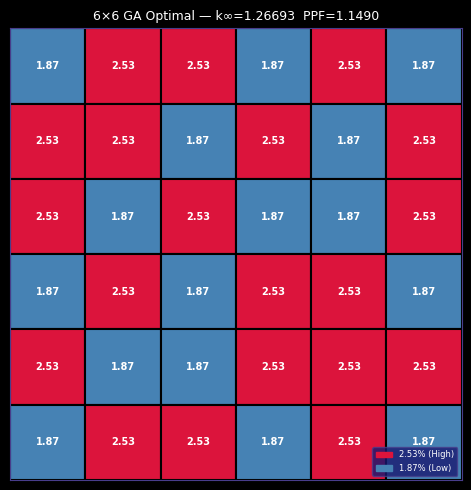

Grid saved → ../Results/BWR_6x6_HP-GA/BWR_6x6_HP-GA_optimal_grid.png


In [16]:
ga_data = run_ga(
    cfg_ga, evaluate_fn,
    verbose              = True,
    selection            = "tournament",
    crossover_method     = "two_point",
    convergence_tol      = 1e-6,
    convergence_patience = 15,     #15
    inject_diversity_every = 20,    #20  #––––––––––––––––> # Injects fresh individuals every 20 generations
    inject_fraction        = 0.10,
)
print ("done")

best         = summarise_ga_results(cfg_ga, ga_data, save=True, verbose=True)
enr_grid_opt = best["enr_grid"]

# Optimal grid plotting
fig_grid, ax = plt.subplots(1, 1, figsize=(5, 5))
fig_grid.patch.set_facecolor("black")
plot_enr_grid(
    enr_grid_opt,
    title = f"{BWR_N}×{BWR_N} GA Optimal — k∞={best['keff']:.5f}  PPF={best['ppf']:.4f}",
    ax    = ax,
)
plt.tight_layout()
grid_path = f"{RESULTS_DIR}/{MODEL_NAME}_optimal_grid.png"
fig_grid.savefig(grid_path, dpi=150, bbox_inches="tight", facecolor="black")
plt.show()
print(f"Grid saved → {grid_path}")

# Convergence plot + text report

Figure saved → ../Results/BWR_6x6_HP-GA/BWR_6x6_HP-GA_ga_convergence.png


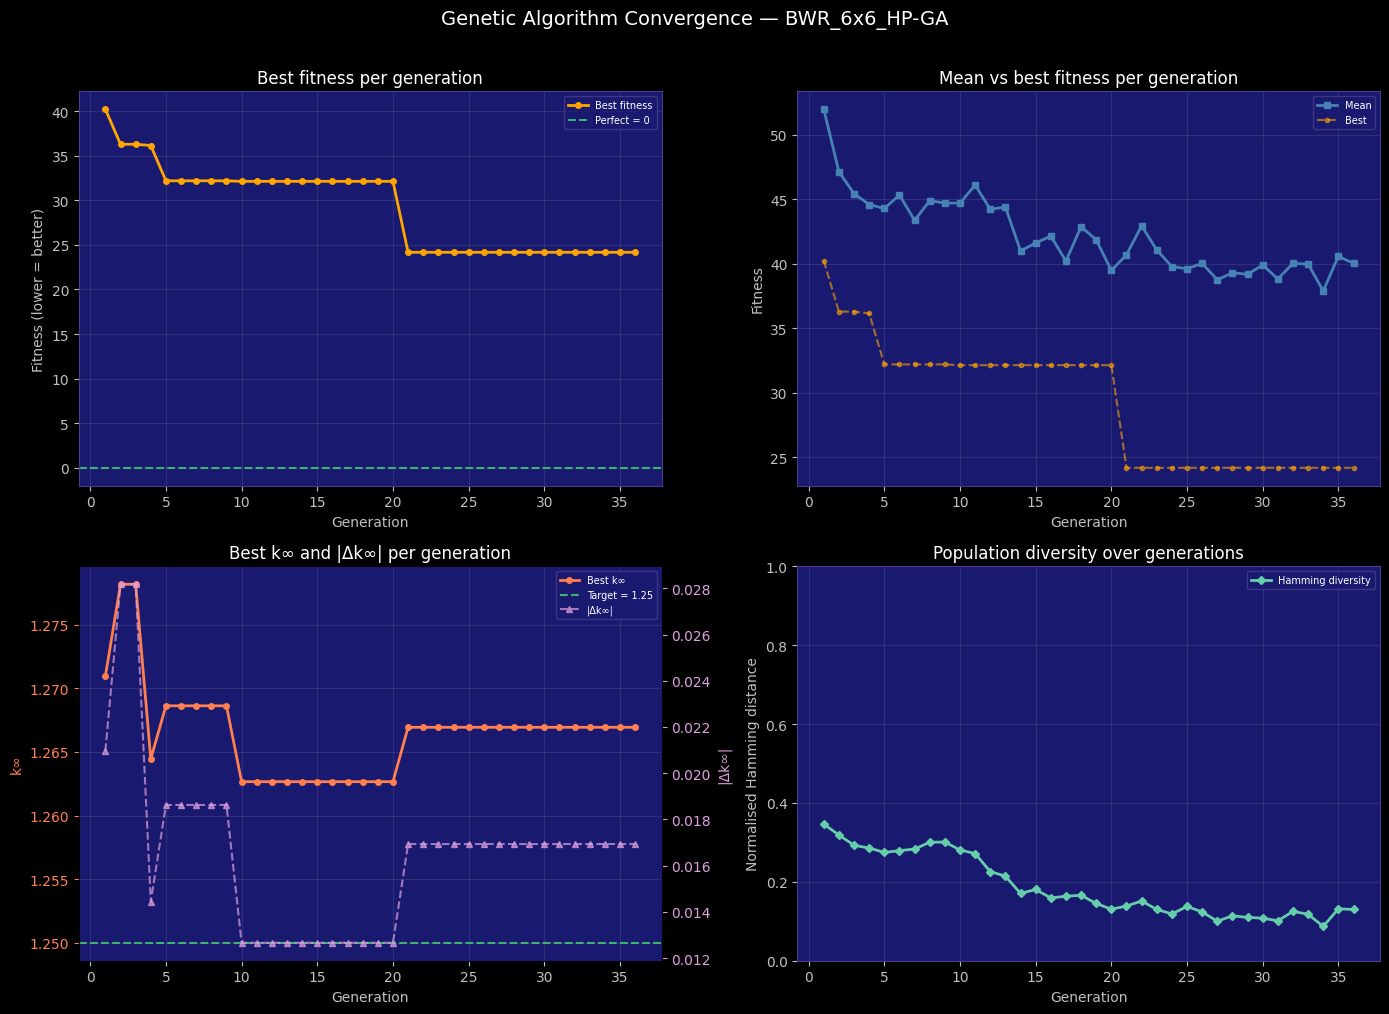

  OPTIMAL 6×6 ENRICHMENT LAYOUT (GA) — BWR_6x6_HP-GA
  Algorithm             : GA
  Assembly size         : 6×6 = 36 fuel pins
  Symmetric positions   : 21  (1/2-diagonal symmetry)
  Enrichment options    : 1.87% (Low)  /  2.53% (High)
  High-enrichment rods  : 20 / 36
  Low-enrichment rods   : 16  / 36
  Average enrichment    : 2.2367 wt%
  k∞                    : 1.26693
  k∞ target             : 1.25
  |Δk∞|                 : 0.01693  (1693.4 pcm)
  PPF                   : 1.1490  (limit ≤ 1.35)
  PPF constraint        : SATISFIED 
  Best fitness          : 24.169336  (0 = perfect)
  HOF chromosome        : [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0]
  GA PARAMETERS
  Population size       : 66
  Generations           : 80
  Crossover rate        : 0.85
  Mutation rate         : 0.15  (2 swap(s)/event)
  Tournament size       : 3
  Elitism count         : 2
  Random seed           : 99
  Corner masking        : True  (weight=N/A)
  Adjacency penalty     : True  (

'../Results/BWR_6x6_HP-GA/optimised_enrichment_layout_ga.txt'

In [17]:
fig_conv = plot_ga_convergence(cfg_ga, ga_data, save=True)
plt.show()

export_design_report(
    cfg          = cfg_ga,
    result_data  = best,
    enr_grid_opt = enr_grid_opt,
    model_params = get_model_params(BWR_N),
    algorithm    = "GA",
)

# Comparison and Validation (Not necessary)

  VALIDATION: HIGH-FIDELITY OpenMC RUNS

[A] Reference layout — random valid enrichment layout with 23 high enrichment rods

[C] GA best layout — HiFi re-evaluation
All done
════════════════════════════════════════════════════════════════════════
  GA VALIDATION COMPARISON — Enrichment Layout Optimisation
════════════════════════════════════════════════════════════════════════
Design                                                k∞   σ(k∞) pcm      PPF
------------------------------------------------------------------------
  A — Reference layout          [HiFi]           1.27165       30.01   1.0930
  B — GA optimal layout         [LoFi]           1.26693       31.62   1.1490
  C — GA optimal layout (re-run)[HiFi]           1.26559       25.70   1.1186
════════════════════════════════════════════════════════════════════════

  Δk∞  (A→C): -0.00605  (-605.4 pcm)
  ΔPPF (A→C): +0.0256
  Δk∞  (B→C): -0.00134  |Z| = 3.29   check particles

Saved → ../Results/BWR_6x6_HP-GA/BWR_6x6_HP-GA_v

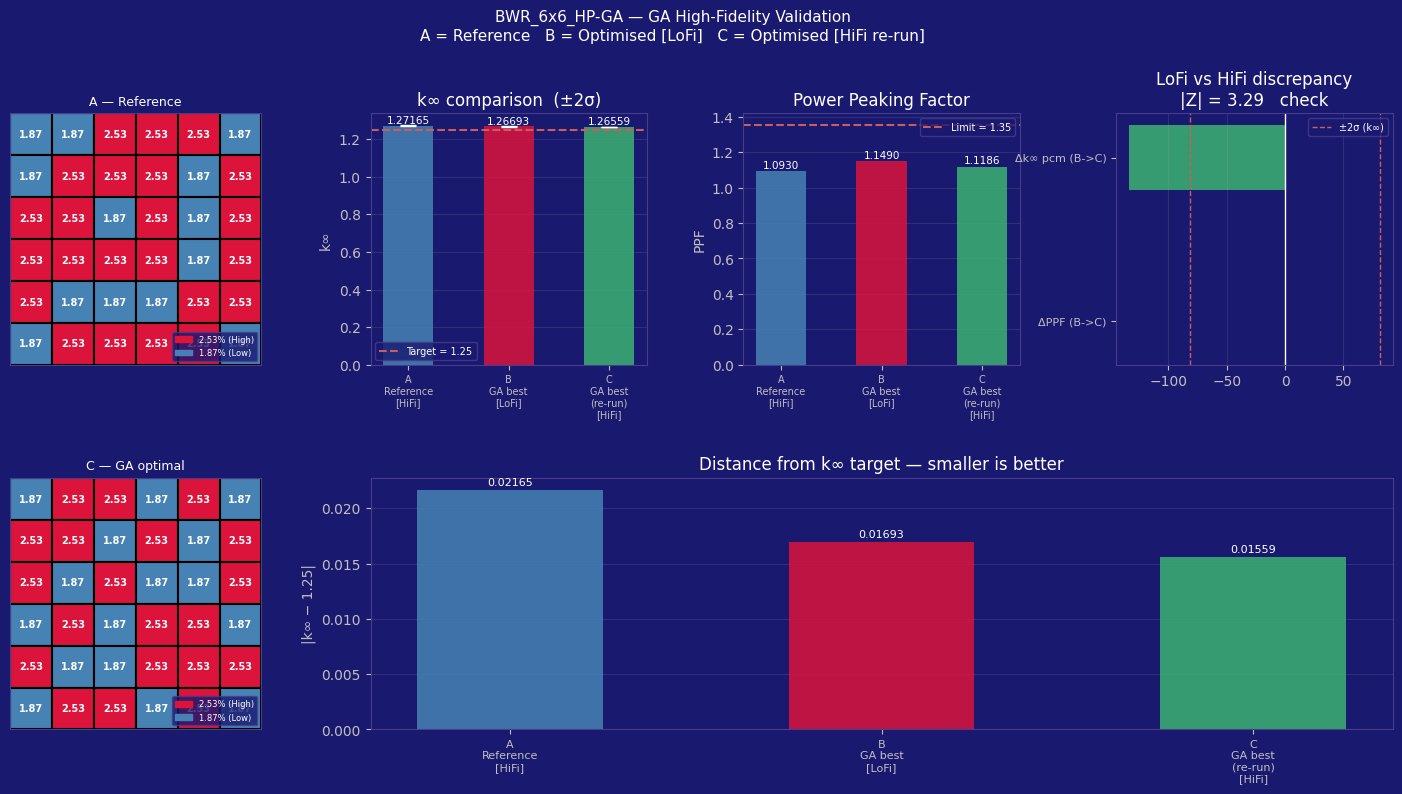

In [18]:
print("=" * 65)
print("  VALIDATION: HIGH-FIDELITY OpenMC RUNS")
print("=" * 65)


cfg_ga.n_particles = 50000  # Set to 50000+ for actual research runs
cfg_ga.n_inactive  = 50
cfg_ga.n_active    = 200


rng = np.random.default_rng(cfg_ga.random_seed)


print(f"\n[A] Reference layout — random valid enrichment layout with {cfg_ga.n_high_rods} high enrichment rods")


x_ref_random = make_random_individual(cfg_ga, rng)
enr_grid_ref = cfg_ga.decode(x_ref_random)
hifi_ref     = evaluate_fn(x_ref_random)
hifi_ref.setdefault("keff_std", 0.0) 


best_lofi = dict(keff=best["keff"], ppf=best["ppf"])

print("\n[C] GA best layout — HiFi re-evaluation")
# Re-run best discrete chromosome at HiFi particle count
hifi_opt = evaluate_fn(best["chromosome"])
hifi_opt.setdefault("keff_std", 0.0)


enr_grid_opt = best["enr_grid"]

print("All done")


fig_val = validate_and_plot_hifi(
    cfg          = cfg_ga,
    hifi_ref     = hifi_ref,
    best_lofi    = best_lofi,
    hifi_opt     = hifi_opt,
    enr_grid_ref = enr_grid_ref,
    enr_grid_opt = enr_grid_opt,
    filename     = f"{MODEL_NAME}_validation.png",
    algorithm    = "GA",
)
plt.show()

In [19]:
print("Keys inside 'best':", best.keys())

Keys inside 'best': dict_keys(['chromosome', 'keff', 'keff_std', 'ppf', 'fitness', 'enr_grid', 'delta_k'])
